# 1. Import thư viện và các Module cần thiết

In [1]:
import os
import sys
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import pandas as pd

# Định nghĩa đường dẫn gốc dự án (PROJECT_DIR)
PROJECT_DIR = Path.cwd().parent
if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

# Import Data Pipeline 
from src.data import DataConfig, build_dataloaders

# Import Training Engine và TensorBoard Utils
from src.trainer import (
    train_one_epoch, 
    validate_one_epoch, 
    train_model, 
    save_checkpoint, 
    get_device
)
from src.tensorboard_utils import TensorBoardLogger

print(f" Đường dẫn dự án (PROJECT_DIR): {PROJECT_DIR}")

 Đường dẫn dự án (PROJECT_DIR): c:\Users\LAM LINH\OneDrive\Tài liệu\DEEP\UTH-Deep-Learning-nhom2\Practice_2


# 2. Nhận DataLoader từ src/data.py (Không chia lại data, dùng seed=42)

In [2]:
# Cấu hình data_dir = PROJECT_DIR / "data"
config = DataConfig(
    data_dir=PROJECT_DIR / "data",
    image_size=224,
    batch_size=32,
    val_ratio=0.10, # Giữ nguyên tỷ lệ 10% validation
    num_workers=2,
    seed=42          # Giữ nguyên seed=42 để dùng chung dữ liệu với cả nhóm
)

# Gọi hàm build_dataloaders dùng chung từ src/data.py
data_dict = build_dataloaders(config)

train_loader = data_dict['train_loader']
val_loader = data_dict['val_loader']
test_loader = data_dict['test_loader']
class_names = data_dict['class_names']

print(" DataLoaders của đã sẵn sàng!")
print(f"- Số lượng batch Train: {len(train_loader)}")
print(f"- Số lượng batch Val:   {len(val_loader)}")
print(f"- Số lượng batch Test:  {len(test_loader)}")
print(f"- Danh sách 10 lớp: {class_names}")

 DataLoaders của đã sẵn sàng!
- Số lượng batch Train: 1407
- Số lượng batch Val:   157
- Số lượng batch Test:  313
- Danh sách 10 lớp: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [3]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

# 1. Tạo thư mục lưu kết quả hình ảnh theo đúng yêu cầu cấu trúc dự án
FIGURES_DIR = PROJECT_DIR / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed=42):
    """
    Đặt seed cố định cho tất cả các thư viện liên quan
    Đảm bảo việc khởi tạo mô hình giữa Adam và SGD hoàn toàn công bằng (giống hệt nhau)
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f" Reset seed về {seed} thành công!")

def save_plot(fig, filename):
    """Hàm tự động lưu hình ảnh biểu đồ vào thư mục Practice_2/results/figures/"""
    save_path = FIGURES_DIR / filename
    fig.savefig(save_path, bbox_inches='tight', dpi=300)
    print(f" Biểu đồ đã được lưu tự động tại: {save_path}")

# 3. Xác định device CPU/GPU

In [4]:
device = get_device()
print(f"Thiết bị tính toán được tự động chọn: {device}")
if device.type == 'cuda':
    print(f" GPU Name: {torch.cuda.get_device_name(0)}")

Thiết bị tính toán được tự động chọn: cpu


# 4. Chuẩn bị model test (ResNet-18)

In [5]:
def create_resnet18_model(num_classes=10):
    """Tải ResNet-18 pre-trained và thay thế lớp classifier 10 đầu ra."""
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model

model_test = create_resnet18_model()
print(" Mô hình ResNet-18 đã được cấu hình sẵn sàng thử nghiệm!")

 Mô hình ResNet-18 đã được cấu hình sẵn sàng thử nghiệm!


# 5. Loss Function 

In [6]:
criterion = nn.CrossEntropyLoss()
print(" Hàm mất mát (Loss Function): CrossEntropyLoss")

 Hàm mất mát (Loss Function): CrossEntropyLoss


# 6. Optimizer (Khởi tạo các tham số huấn luyện)

In [7]:
# Thiết lập các siêu tham số chung cho thí nghiệm so sánh
LR = 0.001
NUM_EPOCHS = 5 # Số epoch chạy thử nghiệm so sánh Optimizer

# 7. Kiểm tra hàm

In [8]:
print("--- Kiểm tra chạy thử 1 Epoch Huấn luyện ---")
demo_model = create_resnet18_model().to(device)
demo_optimizer = optim.Adam(demo_model.parameters(), lr=LR)

# Gọi trực tiếp train_one_epoch()
train_loss_demo, train_acc_demo = train_one_epoch(
    model=demo_model, 
    dataloader=train_loader, 
    criterion=criterion, 
    optimizer=demo_optimizer, 
    device=device
)

print(f"Train 1 Epoch -> Loss: {train_loss_demo:.4f} | Accuracy: {train_acc_demo:.2f}%")

--- Kiểm tra chạy thử 1 Epoch Huấn luyện ---


Training:   1%|          | 13/1407 [00:38<1:07:59,  2.93s/it]


KeyboardInterrupt: 

# 8. Kiểm tra hàm validate_one_epoch()

In [9]:
print("--- Kiểm tra chạy thử 1 Epoch Validation ---")

# Gọi trực tiếp validate_one_epoch()
val_loss_demo, val_acc_demo = validate_one_epoch(
    model=demo_model, 
    dataloader=val_loader, 
    criterion=criterion, 
    device=device
)

print(f"Validation 1 Epoch -> Loss: {val_loss_demo:.4f} | Accuracy: {val_acc_demo:.2f}%")

--- Kiểm tra chạy thử 1 Epoch Validation ---


Validating: 100%|██████████| 157/157 [00:19<00:00,  8.20it/s]


Validation 1 Epoch -> Loss: 0.5762 | Accuracy: 81.14%


# 9, 10, 11, 12, 13. Tích hợp train_model(), Checkpoint & TensorBoard Logging

In [10]:
# Đảm bảo các thư mục checkpoints và runs được khởi tạo đầy đủ
(PROJECT_DIR / "checkpoints").mkdir(parents=True, exist_ok=True)
(PROJECT_DIR / "runs").mkdir(parents=True, exist_ok=True)

print(" Khung hàm train_model() đã tích hợp sẵn:")
print("  - [10] Tự động lưu Best Checkpoint dựa trên Validation Accuracy")
print("  - [11] Khởi tạo TensorBoard Writer")
print("  - [12] Ghi log Train Loss & Validation Loss")
print("  - [13] Ghi log Train Accuracy & Validation Accuracy")

 Khung hàm train_model() đã tích hợp sẵn:
  - [10] Tự động lưu Best Checkpoint dựa trên Validation Accuracy
  - [11] Khởi tạo TensorBoard Writer
  - [12] Ghi log Train Loss & Validation Loss
  - [13] Ghi log Train Accuracy & Validation Accuracy


# 14.1 So sánh Adam và SGD — Thí nghiệm A: Adam

In [11]:

print(" THÍ NGHIỆM A: ResNet-18 + Optimizer ADAM (Seed = 42)")


# Khôi phục seed để khởi tạo trọng số
set_seed(42)

model_adam = create_resnet18_model()
optimizer_adam = optim.Adam(model_adam.parameters(), lr=LR)

log_dir_adam = str(PROJECT_DIR / "runs" / "resnet18_adam")
checkpoint_adam = str(PROJECT_DIR / "checkpoints" / "best_resnet18_adam.pth")

history_adam = train_model(
    model=model_adam,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_adam,
    num_epochs=NUM_EPOCHS,
    log_dir=log_dir_adam,
    checkpoint_path=checkpoint_adam
)

 THÍ NGHIỆM A: ResNet-18 + Optimizer ADAM (Seed = 42)
 Reset seed về 42 thành công!

Epoch [1/5]


Validating: 100%|██████████| 157/157 [00:05<00:00, 27.29it/s]


Train Loss: 0.7397, Train Acc: 74.64%
Val Loss: 0.5560, Val Acc: 81.00%
Validation accuracy improved (0.00% --> 81.00%). Saving model...

Epoch [2/5]


Validating: 100%|██████████| 157/157 [00:05<00:00, 27.57it/s]


Train Loss: 0.4676, Train Acc: 84.06%
Val Loss: 0.4114, Val Acc: 86.58%
Validation accuracy improved (81.00% --> 86.58%). Saving model...

Epoch [3/5]


...

Train Loss: 0.3774, Train Acc: 87.22%
Val Loss: 0.3614, Val Acc: 88.10%
Validation accuracy improved (86.58% --> 88.10%). Saving model...

Epoch [4/5]


Validating: 100%|██████████| 157/157 [00:05<00:00, 27.64it/s]


Train Loss: 0.3203, Train Acc: 88.95%
Val Loss: 0.3636, Val Acc: 87.96%

Epoch [5/5]


Validating: 100%|██████████| 157/157 [00:05<00:00, 27.60it/s]


Train Loss: 0.2777, Train Acc: 90.54%
Val Loss: 0.3259, Val Acc: 88.84%
Validation accuracy improved (88.10% --> 88.84%). Saving model...


# 14.2 So sánh Adam và SGD — Thí nghiệm B: SGD với Momentum

In [12]:

print(" THÍ NGHIỆM B: ResNet-18 + Optimizer SGD (Seed = 42)")

# Khôi phục seed chính xác như Thí nghiệm A để khởi tạo mô hình y hệt nhau
set_seed(42)

model_sgd = create_resnet18_model()
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=LR, momentum=0.9)

log_dir_sgd = str(PROJECT_DIR / "runs" / "resnet18_sgd")
checkpoint_sgd = str(PROJECT_DIR / "checkpoints" / "best_resnet18_sgd.pth")

history_sgd = train_model(
    model=model_sgd,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_sgd,
    num_epochs=NUM_EPOCHS,
    log_dir=log_dir_sgd,
    checkpoint_path=checkpoint_sgd
)

 THÍ NGHIỆM B: ResNet-18 + Optimizer SGD (Seed = 42)
 Reset seed về 42 thành công!

Epoch [1/5]


Validating: 100%|██████████| 157/157 [00:05<00:00, 27.12it/s]


Train Loss: 0.4539, Train Acc: 84.91%
Val Loss: 0.2011, Val Acc: 93.00%
Validation accuracy improved (0.00% --> 93.00%). Saving model...

Epoch [2/5]


Validating: 100%|██████████| 157/157 [00:05<00:00, 27.91it/s]


Train Loss: 0.2120, Train Acc: 92.94%
Val Loss: 0.1621, Val Acc: 94.26%
Validation accuracy improved (93.00% --> 94.26%). Saving model...

Epoch [3/5]


...

Train Loss: 0.1516, Train Acc: 94.80%
Val Loss: 0.1448, Val Acc: 95.16%
Validation accuracy improved (94.26% --> 95.16%). Saving model...

Epoch [4/5]


Validating: 100%|██████████| 157/157 [00:05<00:00, 28.09it/s]


Train Loss: 0.1223, Train Acc: 95.94%
Val Loss: 0.1322, Val Acc: 95.76%
Validation accuracy improved (95.16% --> 95.76%). Saving model...

Epoch [5/5]


Validating: 100%|██████████| 157/157 [00:05<00:00, 27.25it/s]

Train Loss: 0.0973, Train Acc: 96.79%
Val Loss: 0.1289, Val Acc: 95.68%


# 15. Tổng hợp Bảng so sánh kết quả

In [13]:
results_data = [
    {
        "Optimizer": "Adam",
        "Learning Rate": LR,
        "Best Val Acc (%)": max(history_adam['val_acc']),
        "Min Val Loss": min(history_adam['val_loss']),
        "Final Train Acc (%)": history_adam['train_acc'][-1],
        "Final Val Acc (%)": history_adam['val_acc'][-1]
    },
    {
        "Optimizer": "SGD + Momentum (0.9)",
        "Learning Rate": LR,
        "Best Val Acc (%)": max(history_sgd['val_acc']),
        "Min Val Loss": min(history_sgd['val_loss']),
        "Final Train Acc (%)": history_sgd['train_acc'][-1],
        "Final Val Acc (%)": history_sgd['val_acc'][-1]
    }
]

df_compare = pd.DataFrame(results_data)
print("\n BẢNG SO SÁNH KẾT QUẢ TỐI ƯU HÓA:")
display(df_compare)


 BẢNG SO SÁNH KẾT QUẢ TỐI ƯU HÓA:


,Optimizer,Learning Rate,Best Val Acc (%),Min Val Loss,Final Train Acc (%),Final Val Acc (%)
0,Adam,0.001,88.84,0.325913,90.535556,88.84
1,SGD + Momentum (0.9),0.001,95.76,0.128892,96.788889,95.68


# 16. Vẽ Biểu Đồ & Lưu Ảnh

 Biểu đồ đã được lưu tự động tại: q:\Deep_Learning\UTH-Deep-Learning-nhom2\Practice_2\results\figures\adam_vs_sgd_curves.png


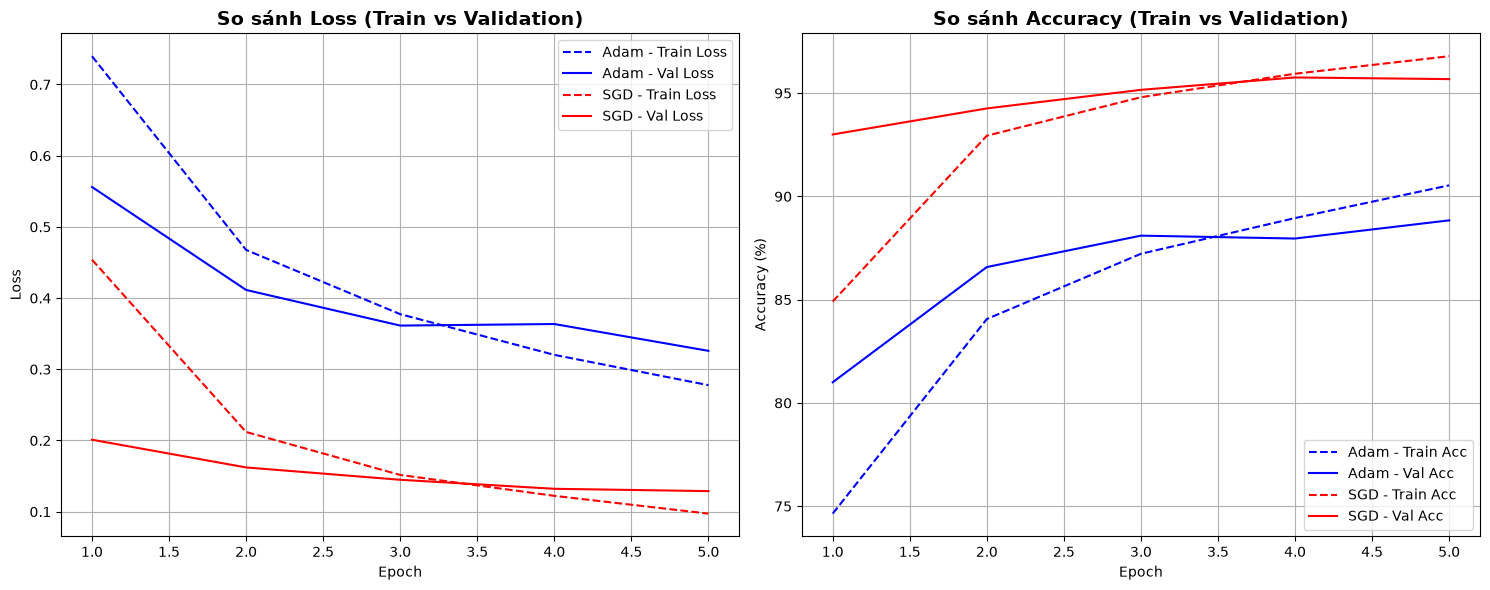

In [14]:
epochs = list(range(1, NUM_EPOCHS + 1))

# --- 1. VẼ VÀ LƯU BIỂU ĐỒ SỰ KHÁC BIỆT LOSS & ACCURACY ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Đồ thị 1: Train Loss vs Validation Loss
axes[0].plot(epochs, history_adam['train_loss'], 'b--', label='Adam - Train Loss')
axes[0].plot(epochs, history_adam['val_loss'], 'b-', label='Adam - Val Loss')
axes[0].plot(epochs, history_sgd['train_loss'], 'r--', label='SGD - Train Loss')
axes[0].plot(epochs, history_sgd['val_loss'], 'r-', label='SGD - Val Loss')
axes[0].set_title('So sánh Loss (Train vs Validation)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Đồ thị 2: Train Accuracy vs Validation Accuracy
axes[1].plot(epochs, history_adam['train_acc'], 'b--', label='Adam - Train Acc')
axes[1].plot(epochs, history_adam['val_acc'], 'b-', label='Adam - Val Acc')
axes[1].plot(epochs, history_sgd['train_acc'], 'r--', label='SGD - Train Acc')
axes[1].plot(epochs, history_sgd['val_acc'], 'r-', label='SGD - Val Acc')
axes[1].set_title('So sánh Accuracy (Train vs Validation)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()

# Gọi hàm lưu ảnh tự động vào results/figures/
save_plot(fig, "adam_vs_sgd_curves.png")
plt.show()

# 17.Xuất và Lưu Minh Chứng từ Log TensorBoard

Found more than one graph event per run, or there was a metagraph containing a graph_def, as well as one or more graph events.  Overwriting the graph with the newest event.
Found more than one "run metadata" event with tag step1. Overwriting it with the newest event.
Found more than one graph event per run, or there was a metagraph containing a graph_def, as well as one or more graph events.  Overwriting the graph with the newest event.
Found more than one "run metadata" event with tag step1. Overwriting it with the newest event.


 Biểu đồ đã được lưu tự động tại: q:\Deep_Learning\UTH-Deep-Learning-nhom2\Practice_2\results\figures\tensorboard_logs_proof.png


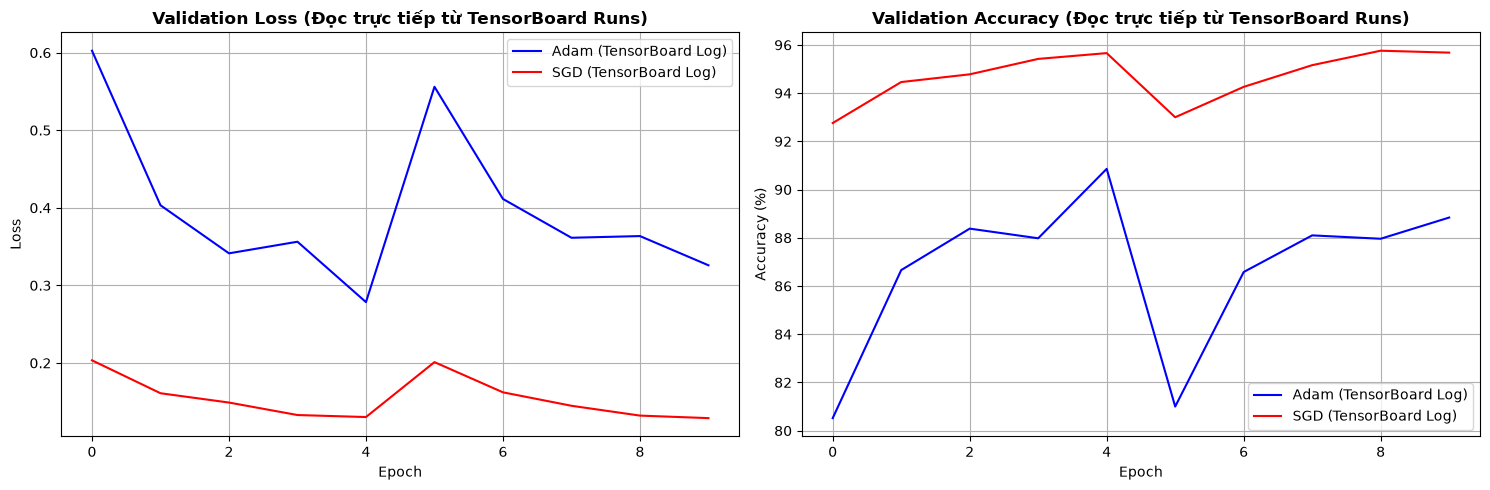

In [15]:
from tensorboard.backend.event_processing import event_accumulator

def extract_tensorboard_scalars(log_dir):
    """Đọc dữ liệu scalars trực tiếp từ file log của TensorBoard."""
    ea = event_accumulator.EventAccumulator(log_dir)
    ea.Reload()
    
    tags = ea.Tags()['scalars']
    data = {}
    for tag in tags:
        events = ea.Scalars(tag)
        data[tag] = [e.value for e in events]
    return data

# Đọc log TensorBoard của Adam & SGD
tb_data_adam = extract_tensorboard_scalars(log_dir_adam)
tb_data_sgd = extract_tensorboard_scalars(log_dir_sgd)

# Vẽ biểu đồ kiểm chứng từ dữ liệu thu thập của TensorBoard
fig_tb, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Đồ thị Validation Loss thu từ TensorBoard Log
ax1.plot(tb_data_adam['Loss/Validation'], label='Adam (TensorBoard Log)', color='blue')
ax1.plot(tb_data_sgd['Loss/Validation'], label='SGD (TensorBoard Log)', color='red')
ax1.set_title('Validation Loss (Đọc trực tiếp từ TensorBoard Runs)', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Đồ thị Validation Accuracy thu từ TensorBoard Log
ax2.plot(tb_data_adam['Accuracy/Validation'], label='Adam (TensorBoard Log)', color='blue')
ax2.plot(tb_data_sgd['Accuracy/Validation'], label='SGD (TensorBoard Log)', color='red')
ax2.set_title('Validation Accuracy (Đọc trực tiếp từ TensorBoard Runs)', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()

# Lưu minh chứng TensorBoard vào thư mục results/figures/
save_plot(fig_tb, "tensorboard_logs_proof.png")
plt.show()